# Moving Average Crossover Backtest: AAPL (refactored)

This is a refactor of `Backtesting_v1.ipynb` — same strategy, same data, same assumptions, just moved into `backtest.py` so the logic can be reused for the parameter sweep in v2. It should reproduce v1's numbers except for a one-day shift in the CAGR denominator (see the note in "Checking the risk side" below) — a bug fix, not a methodology change.

**v1 result (with transaction costs):**
- Buy & Hold: 31.06% CAGR, 0.94 Sharpe, -33.36% max drawdown
- Strategy: 18.81% CAGR, 0.78 Sharpe, -28.36% max drawdown

The strategy is simple: when a short-term average price crosses above a long-term average, that's a buy signal, and when it crosses below, that's a sell signal — one of the most common beginner strategies in trading.

**What's different from v1:**
- The backtest logic (SMA/signal/position/costs/risk-free cash, plus `max_drawdown`, `cagr`, `sharpe`, `summarize`) now lives in `backtest.py` as reusable functions instead of one-off notebook cells
- Price and T-bill data are cached to CSV instead of re-downloaded on every run
- Fixed an off-by-one in `cagr` (it was subtracting an extra day from the period count)

**Tools:** `yfinance`, `pandas`, `NumPy`, `Matplotlib`

## Getting the data

I pulled daily AAPL price data from 2019 to early 2026 using `backtest.load_prices`, which wraps yfinance with `auto_adjust=True` so prices are split and dividend adjusted, and caches the result to `data/` so re-running this notebook doesn't re-download every time. This range covers a bunch of different market conditions, specifically the COVID-19 crash, 2022 downturn and even a long recovery, so it's a normal stretch to actually test a strategy on.

In [1]:
import backtest as bt

prices = bt.load_prices("AAPL", "2019-01-01", "2026-01-01")
prices.head()

Date
2019-01-02    37.436916
2019-01-03    33.707916
2019-01-04    35.146889
2019-01-07    35.068657
2019-01-08    35.737179
Name: Close, dtype: float64

## Moving averages and the signal

`backtest.backtest` calculates a 20-day and a 50-day moving average from the closing price, and builds the signal from their crossover: when the 20-day average is above the 50-day average, the signal is 1 (holding the stock), and when it's below, the signal is 0 (sitting out in cash). The position actually held is the signal lagged by one day, so today's return is only earned using information known at the start of the day — no look-ahead.

During the first 49 days, the 50-day average hasn't warmed up yet, so those rows are dropped before the position is computed, rather than silently treated as "sit out".

When the strategy is out of the market, cash earns the actual historical 13-week T-bill rate for that date (`^IRX`, via `backtest.load_risk_free`), rather than a flat guess — this matters since T-bills have paid a meaningful yield for a lot of this period. If that download fails, it falls back to a flat 4% annual rate. Every time the position changes, a small transaction cost (5 bps, one-way) is charged, since real trading isn't free.

In [2]:
SHORT_WINDOW = 20
LONG_WINDOW = 50
COST_BPS = 5.0

rf_daily = bt.load_risk_free(prices.index)
result = bt.backtest(prices, SHORT_WINDOW, LONG_WINDOW, cost_bps=COST_BPS, rf_daily=rf_daily)
result[["close", "sma_short", "sma_long", "signal", "position", "strat_ret"]].tail(10)

,close,sma_short,sma_long,signal,position,strat_ret
Date,,,,,,
2025-12-17,271.102051,276.209671,267.996823,1,1.0,-0.010087
2025-12-18,271.451141,276.390680,268.283640,1,1.0,0.001288
2025-12-19,272.927124,276.760674,268.680082,1,1.0,0.005437
2025-12-22,270.234436,276.734746,269.197425,1,1.0,-0.009866
2025-12-23,271.620667,276.557228,269.694868,1,1.0,0.005130
2025-12-24,273.066711,276.399655,270.219040,1,1.0,0.005324
2025-12-26,272.657806,276.192717,270.703749,1,1.0,-0.001497
2025-12-29,273.016876,275.938908,271.233301,1,1.0,0.001317
2025-12-30,272.338684,275.439267,271.652845,1,1.0,-0.002484


## Checking how often it actually trades

Before looking at returns, it's worth seeing how active this strategy actually is — how many times it flipped in and out of the market, how long it typically stayed in a position, and what fraction of the time it was invested at all.

In [3]:
stats = bt.trade_stats(result["position"])

print(f"Round-trip trades: {stats['RoundTripTrades']:.0f}")
print(f"Average holding period: {stats['AvgHoldingDays']:.1f} trading days")
print(f"Percent of days in market: {stats['PctDaysInMarket']:.1f}%")

Round-trip trades: 18
Average holding period: 61.8 trading days
Percent of days in market: 65.0%


## Adding it all up

This compounds the daily returns over time, so I can see how $1 would have grown if I just held the stock versus if I followed the strategy the whole way through.

In [4]:
result[["equity_bh", "equity_strategy"]].tail(10)

,equity_bh,equity_strategy
Date,,
2025-12-17,6.266605,3.217944
2025-12-18,6.274674,3.222087
2025-12-19,6.308792,3.239607
2025-12-22,6.246550,3.207645
2025-12-23,6.278593,3.224099
2025-12-24,6.312019,3.241264
2025-12-26,6.302567,3.236410
2025-12-29,6.310867,3.240672
2025-12-30,6.295190,3.232622


## Plotting it out

This graph shows both return curves. The strategy line is flatter as it spends real time out of the market, which caps both its losses and its gains. The gaps between the two lines widen sharply during the strongest recovery stretches (2023 and 2024-25), since that's exactly when the strategy tends to be lagging back into a position rather than already in it.

Matplotlib is building the font cache; this may take a moment.


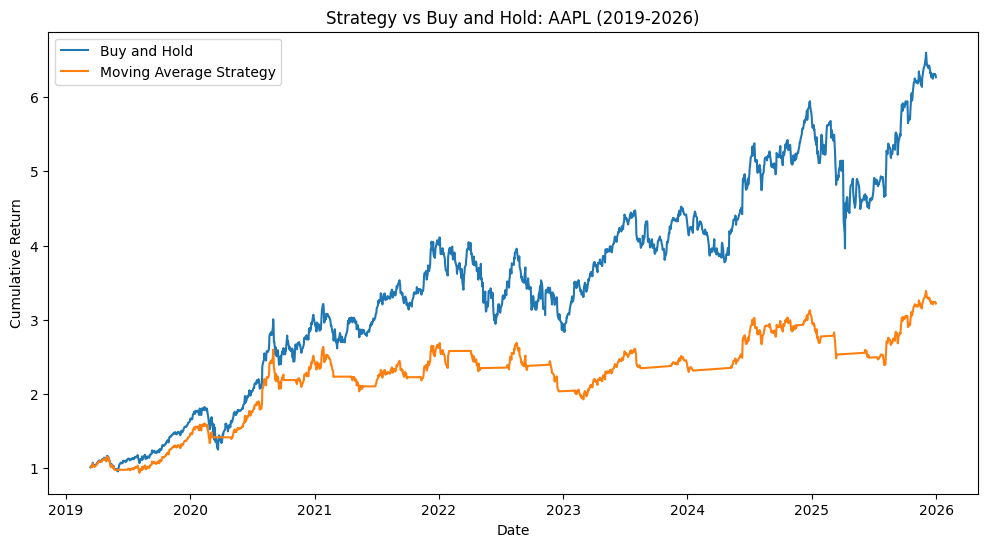

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(result["equity_bh"], label="Buy and Hold")
plt.plot(result["equity_strategy"], label="Moving Average Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Strategy vs Buy and Hold: AAPL (2019-2026)")
plt.legend()
plt.show()

## Seeing the whipsaws directly

The graph shows overall performance, but not *why* the strategy underperforms. This next plot overlays both moving averages on price itself, with the periods the strategy was actually in the market shaded, this makes the whipsaw effect visible directly, rather than just inferred from the return gap.

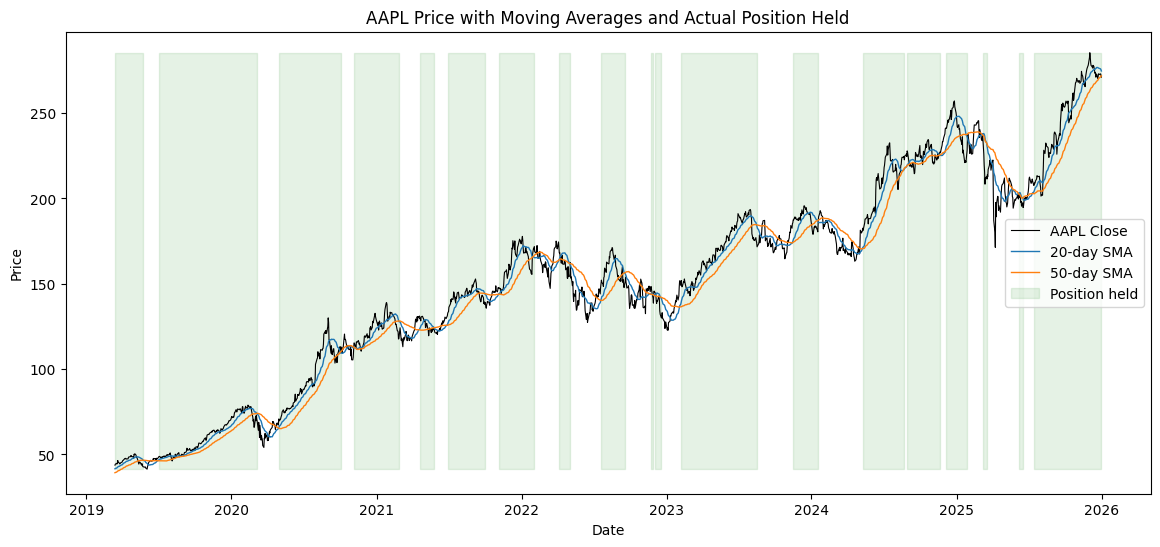

In [6]:
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(result["close"], label="AAPL Close", color="black", linewidth=0.8)
ax.plot(result["sma_short"], label=f"{SHORT_WINDOW}-day SMA", linewidth=1)
ax.plot(result["sma_long"], label=f"{LONG_WINDOW}-day SMA", linewidth=1)
ax.fill_between(result.index, result["close"].min(), result["close"].max(),
                where=result["position"]==1, alpha=0.1, color="green", label="Position held")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.set_title("AAPL Price with Moving Averages and Actual Position Held")
ax.legend()
plt.show()

## Checking the risk side

Returns aren't the whole story, a strategy that makes less money but also loses less during a crash can still be worth something. Max drawdown shows the biggest drop each approach took from its peak.

One methodology fix from v1: `cagr` used to divide by `equity.count() - 1` return periods instead of `equity.count()`. There are no NaNs left in the buy-and-hold curve, so that extra `-1` was just discarding one real trading day from the denominator. The strategy curve does carry one leading NaN (the very first row has no prior day's signal left to shift from once the warm-up period is dropped, so its position is undefined) — `.count()` already excludes that correctly, and no longer double-counts it the way `count() - 1` did. Fixing this shifts both CAGR figures very slightly (a fraction of a percentage point); it isn't a methodology change, it's correcting an annualization bug.

=== With transaction costs ===
Buy and Hold  -  CAGR: 31.04%, Max Drawdown: -33.36%, Sharpe: 0.94
Strategy      -  CAGR: 18.80%, Max Drawdown: -28.36%, Sharpe: 0.78

=== Strategy without transaction costs (for comparison) ===
Strategy (no costs) - CAGR: 19.11%, Max Drawdown: -28.15%, Sharpe: 0.79


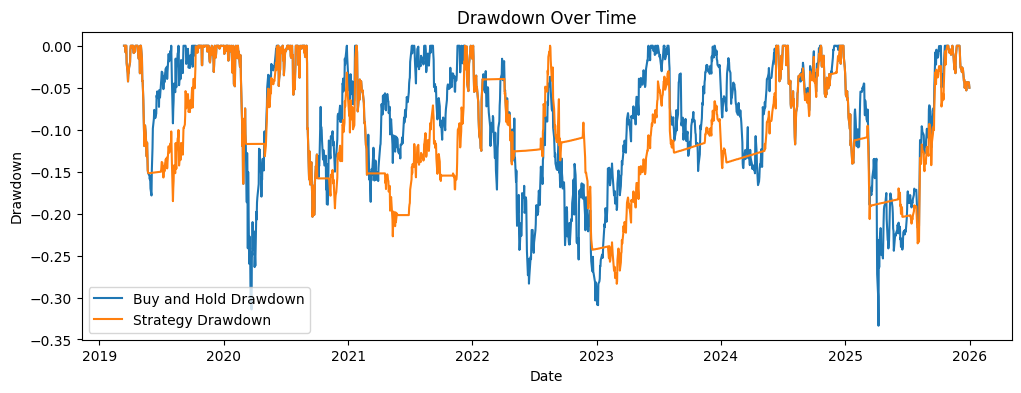

In [7]:
# with transaction costs (the realistic version)
market_summary = bt.summarize(result["equity_bh"], result["ret"].dropna(), rf_daily)
strategy_summary = bt.summarize(result["equity_strategy"], result["strat_ret"].dropna(), rf_daily)

# without transaction costs, for comparison
result_no_costs = bt.backtest(prices, SHORT_WINDOW, LONG_WINDOW, cost_bps=0.0, rf_daily=rf_daily)
strategy_summary_no_costs = bt.summarize(result_no_costs["equity_strategy"], result_no_costs["strat_ret"].dropna(), rf_daily)

print("=== With transaction costs ===")
print(f"Buy and Hold  -  CAGR: {market_summary['CAGR']:.2%}, Max Drawdown: {market_summary['MaxDrawdown']:.2%}, Sharpe: {market_summary['Sharpe']:.2f}")
print(f"Strategy      -  CAGR: {strategy_summary['CAGR']:.2%}, Max Drawdown: {strategy_summary['MaxDrawdown']:.2%}, Sharpe: {strategy_summary['Sharpe']:.2f}")
print()
print("=== Strategy without transaction costs (for comparison) ===")
print(f"Strategy (no costs) - CAGR: {strategy_summary_no_costs['CAGR']:.2%}, Max Drawdown: {strategy_summary_no_costs['MaxDrawdown']:.2%}, Sharpe: {strategy_summary_no_costs['Sharpe']:.2f}")

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(market_summary["DrawdownSeries"], label="Buy and Hold Drawdown")
ax.plot(strategy_summary["DrawdownSeries"], label="Strategy Drawdown")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.set_title("Drawdown Over Time")
ax.legend()
plt.show()

## Sanity check: does the cost drag reconcile?

Comparing the two CAGR figures suggested the transaction costs were roughly double what the trade count implied. Rather than trust that, here's a direct check: the round-trip trade count implies a certain cumulative cost drag at 5 bps per one-way position change, and comparing final equity with and without costs gives the actual number below.

In [8]:
turnover = result["position"].diff().abs().fillna(0)

print("Total turnover (one-way position changes):", turnover.sum())
print()
print("Final multiple with costs:", strategy_summary["FinalMultiple"])
print("Final multiple without costs:", strategy_summary_no_costs["FinalMultiple"])
implied_drag = strategy_summary_no_costs["FinalMultiple"] / strategy_summary["FinalMultiple"] - 1
expected_drag = turnover.sum() * (COST_BPS / 1e4)
print(f"Implied cumulative cost drag: {implied_drag:.2%}")
print(f"Expected cumulative cost drag (trades x cost): {expected_drag:.2%}")

Total turnover (one-way position changes): 36.0

Final multiple with costs: 3.2181804720662055
Final multiple without costs: 3.276633382373101
Implied cumulative cost drag: 1.82%
Expected cumulative cost drag (trades x cost): 1.80%


## Assumptions and limitations

- Long/flat only — no short positions
- Full capital committed on every trade, no partial position sizing
- Fills happen at the closing price of the signal day, not the next day's open
- Single ticker, single parameter pair (20/50) — a multi-asset, multi-parameter check is a separate follow-up
- Cash return while out of the market uses the actual historical 13-week T-bill rate where available, falling back to a flat 4% estimate if that data can't be pulled

## What I found

Buy and hold clearly won on returns, even after accounting for transaction costs. Looking at the risk-adjusted numbers tells the same story — see the printed figures above for the exact numbers from this run.

The strategy's round-trip trade count, time in market, and average holding period are printed above too. Transaction costs are a real but fairly small drag, verified directly by comparing final returns with and without costs. The underperformance against buy-and-hold isn't really about trading fees, it's about missing time in the market during recoveries.

This tracks with what's expected: simple moving average strategies tend to get whipsawed out of the market during choppy stretches and miss the sharp early days of recoveries, which adds up significantly over a long bull run like AAPL's. It's also worth noting AAPL was not a neutral pick — it grew substantially over this window, which stacks the deck toward buy-and-hold before the strategy is even tested. That's exactly what the v2 sweep across a broader ticker universe is meant to check.

## Where this could go further

This strategy is about as simple as trend following gets, and that's kind of the point. A few honest directions this could go:

- **Parameter and universe robustness testing:** right now this is one asset and one parameter pair — a sample size of one. A planned follow-up will run this same strategy across a bunch of different stocks and window combinations to check whether this result actually holds up generally, or if it's specific to AAPL's exact price path over this exact period.

- **Walk-forward validation:** the 20/50 windows were picked once and tested on the full history. A more honest test would pick parameters using only past data at each point in time and test forward from there, so the result isn't quietly benefiting from hindsight.

- **Multiple-testing correction:** once a parameter sweep is run, some combinations will look good just by chance. Worth being careful about treating any single good-looking result as a real finding rather than noise.

- **Multiple signals combined:** adding something like RSI sounds like it should help, but it also adds more free parameters, and technical indicators tend to be pretty correlated with each other anyway. The real question isn't whether adding RSI seems reasonable, it's whether it adds anything once you account for the extra parameters it introduces.

- **Position sizing:** right now the strategy is either fully in or fully out. A more advanced version might scale position size based on signal strength or volatility, rather than a hard on/off switch.

- **Different asset classes:** trend following strategies like this tend to perform better in commodities or currency markets than in a single high-growth stock like AAPL, since those markets often have longer, cleaner trends.

- **Machine learning based signals:** with about 1,700 daily observations on a single stock, there isn't a lot of real signal to learn from compared to noise. A flexible model would probably overfit before it actually learned anything useful. If ML shows up here at all, it'd make more sense as a way to combine a few existing signals together under strict walk-forward validation, not as something trying to find patterns directly in raw price data.

This project started as a simple first step into backtesting, and turned into a decent lesson in why single-asset, single-parameter results shouldn't be taken at face value.